In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [ ]:
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        # filling missing values with the mode for categorial features
        train_data[column].fillna(train_data[column].mode()[0], inplace=True)
        if column in test_data.columns:
            test_data[column].fillna(test_data[column].mode()[0], inplace=True)
    else:
        # filling missing values with the mean for numeric features
        train_data[column].fillna(train_data[column].mean(), inplace=True)
        if column in test_data.columns:
            test_data[column].fillna(test_data[column].mean(), inplace=True)

# selectt features
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
x = train_data[features]
y = train_data['SalePrice']

#Split the Training data for validation
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

#Train the model
model = LinearRegression()
model.fit(X_train, y_train)

In [4]:
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

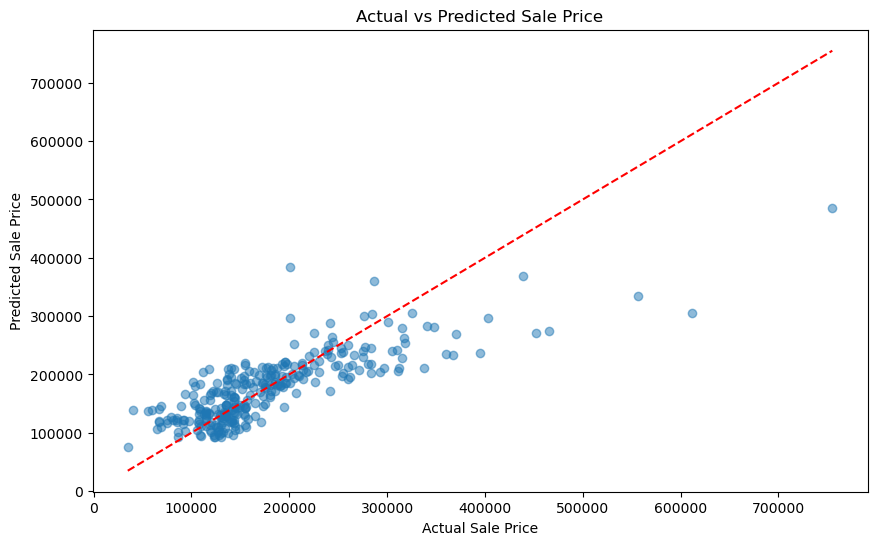

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

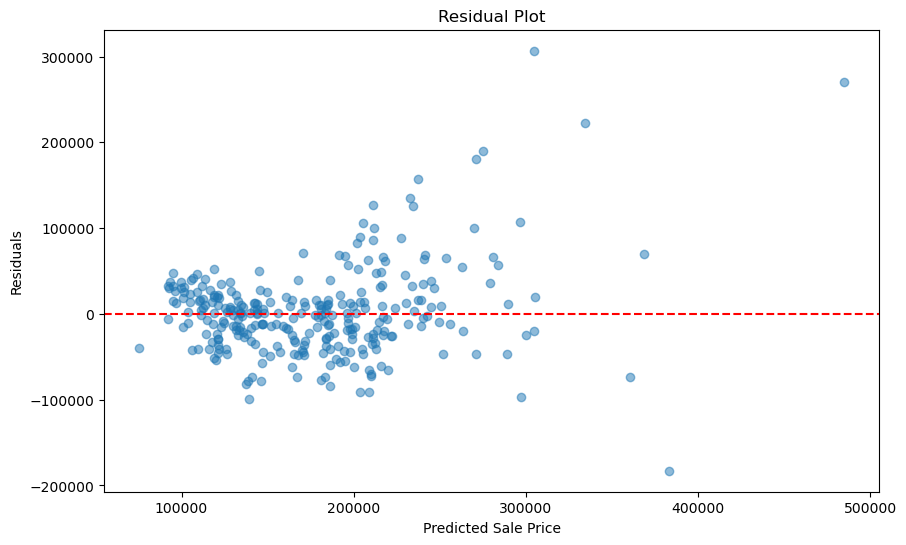

In [6]:
residuals = y_val - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

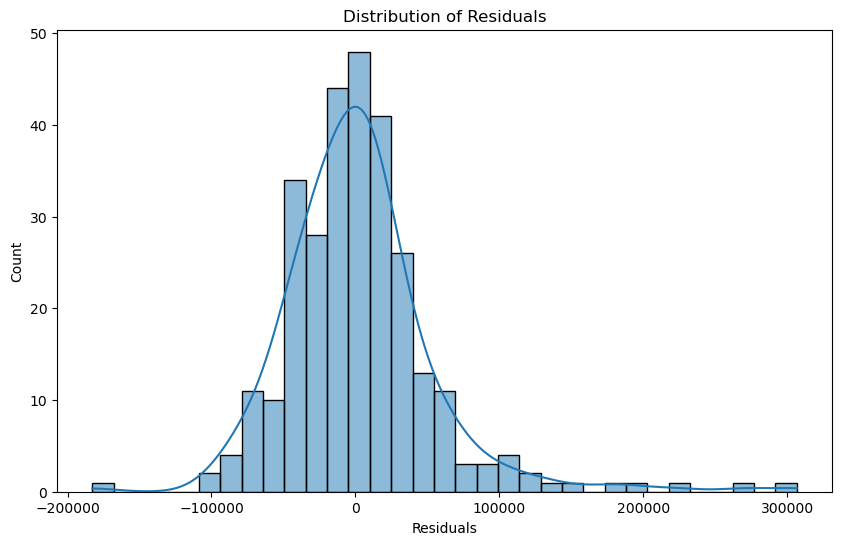

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.show()

<Figure size 1200x0 with 0 Axes>

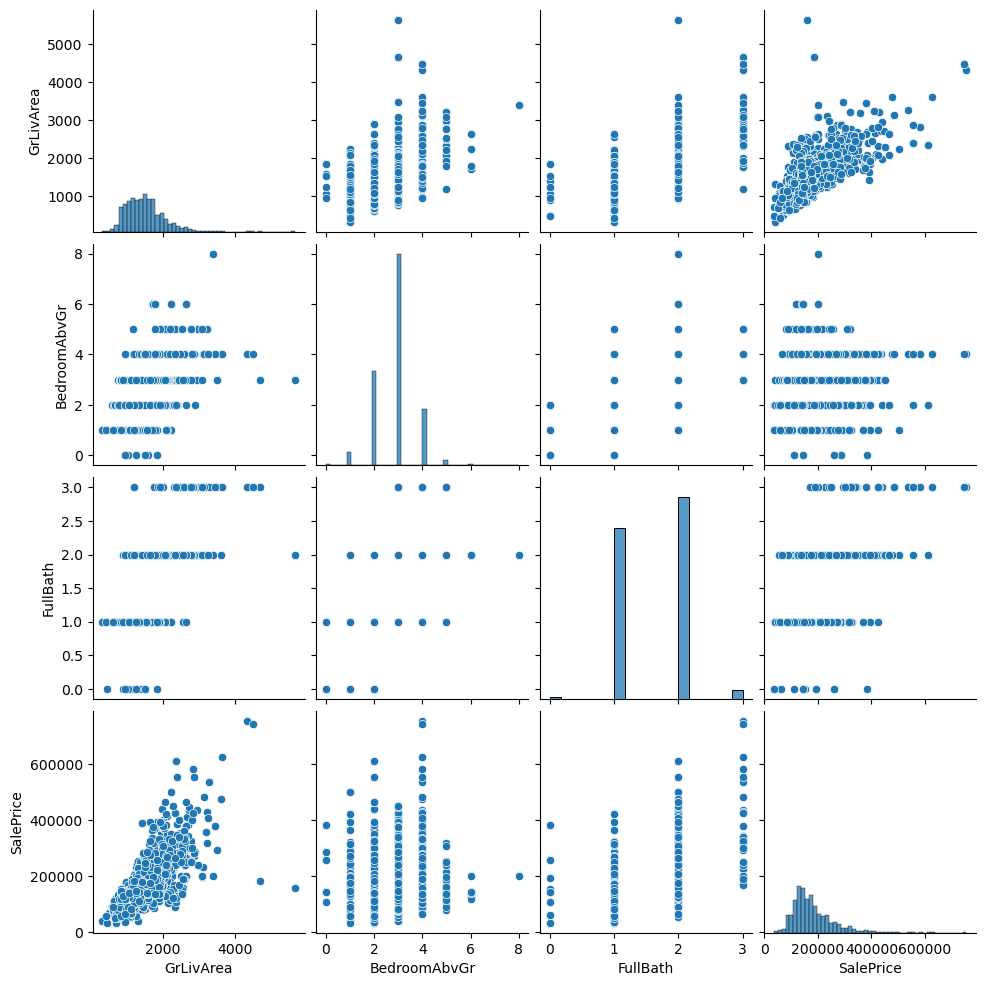

In [8]:
plt.figure(figsize=(12, 0))
sns.pairplot(train_data[features + ['SalePrice']])
plt.show()

In [10]:
example = pd.DataFrame({'GrLivArea': [2000], 'BedroomAbvGr': [3], 'FullBath': [2]})
example_prediction = model.predict(example)
print(f'Example Prediction: ${example_prediction[0]:,.2f}')

# Prepare the test data and make predictions
X_test = test_data[features]
test_predictions = model.predict(X_test)

#Save predictions
submission = pd.DataFrame({'Id': test_data['Id'], 'SalePrice': test_predictions})
submission.to_csv('submission.csv', index=False)

Example Prediction: $240,377.51
